In [1]:
HAI_DIR   = 'C:/Users/ahmma/Desktop/farah/hai-23.05'
HIEND_DIR = 'C:/Users/ahmma/Desktop/farah/haiend-23.05'

# Window Size Analysis — HAI + HAIEnd (Train 1–4)

Goal: find the best sliding-window size for sequence models (LSTM, Transformer, VAE, Diffusion)  
trained on the merged 277-feature dataset, using **only the benign training splits** (train1–4).

## Approach
| Section | Signal | What it tells us |
|---------|--------|------------------|
| 1. ACF decay | Autocorrelation per sensor | Minimum window to capture serial dependence |
| 2. FFT periodicity | Dominant cycle lengths | Window must cover ≥1 full operational cycle |
| 3. PCA reconstruction | Variance explained per window size | Elbow = diminishing information gain |
| 4. Summary | All evidence combined | Final recommendation |


In [2]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.signal import welch
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import acf

from utils.data_loader import load_merged
from utils.normalize import HAISensorNormalizer

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Imports OK')

Imports OK


In [3]:
# ── Load & concatenate all four training splits ──────────────────────────────
dfs = []
for i in range(1, 5):
    df = load_merged('train', i)
    df['split'] = i
    dfs.append(df)

train_all = pd.concat(dfs, ignore_index=True)

# Sensor columns only (drop timestamp, attack, split)
meta_cols = {'timestamp', 'attack', 'split'}
sensor_cols = [c for c in train_all.select_dtypes(include=[np.number]).columns
               if c.lower() not in meta_cols]

print(f'Total rows : {len(train_all):,}')
print(f'Sensor cols: {len(sensor_cols)}')
print(f'Split sizes: {[len(d) for d in dfs]}')

[train1] merged: 280799 rows, 279 cols (dropped 34 duplicate HAI cols)
[train2] merged: 291599 rows, 279 cols (dropped 34 duplicate HAI cols)
[train3] merged: 125999 rows, 279 cols (dropped 34 duplicate HAI cols)
[train4] merged: 197999 rows, 279 cols (dropped 34 duplicate HAI cols)
Total rows : 896,396
Sensor cols: 277
Split sizes: [280799, 291599, 125999, 197999]


In [4]:
# ── Normalise (z-score, fit on train_all) ────────────────────────────────────
norm = HAISensorNormalizer(method='zscore')
norm.fit(train_all[sensor_cols])

# Keep per-split arrays for split-by-split ACF/FFT
split_arrays = {}
for i, df in enumerate(dfs, start=1):
    X = norm.transform(df[sensor_cols]).values.astype(np.float32)
    split_arrays[i] = X

X_all = norm.transform(train_all[sensor_cols]).values.astype(np.float32)

# Remove near-constant columns (std < 0.05 after z-scoring → still noisy)
stds = X_all.std(axis=0)
variable_mask = stds > 0.05
variable_idx  = np.where(variable_mask)[0]
print(f'Variable sensors (std > 0.05): {variable_mask.sum()} / {len(sensor_cols)}')

Variable sensors (std > 0.05): 108 / 277


---
## Section 1 — Autocorrelation Function (ACF) Decay

The ACF at lag _k_ measures how strongly a sensor's value at time _t_ predicts its value at _t+k_.  
Once ACF drops below a significance threshold (~0.05), adding more history gives little extra information.

**Rule of thumb**: choose `window_size` ≥ the lag where the *median* sensor ACF crosses the threshold.


In [5]:
MAX_LAG      = 300   # seconds — upper bound we'll test
ACF_THRESH   = 0.05  # significance threshold
N_SAMPLE_COL = 60    # number of variable sensors to sample (speed)

rng = np.random.default_rng(42)
sampled_idx = rng.choice(variable_idx, size=min(N_SAMPLE_COL, len(variable_idx)), replace=False)

# Compute ACF on the concatenated series for each sampled sensor
acf_matrix = np.zeros((len(sampled_idx), MAX_LAG + 1), dtype=np.float32)

for row, col_i in enumerate(sampled_idx):
    series = X_all[:, col_i].astype(float)
    try:
        acf_vals = acf(series, nlags=MAX_LAG, fft=True, missing='drop')
        acf_matrix[row] = acf_vals
    except Exception:
        acf_matrix[row] = 0.0

acf_mean   = np.nanmean(np.abs(acf_matrix), axis=0)
acf_median = np.nanmedian(np.abs(acf_matrix), axis=0)
acf_p75    = np.nanpercentile(np.abs(acf_matrix), 75, axis=0)

# Find first lag where median ACF drops below threshold
lags = np.arange(MAX_LAG + 1)
cross_lag_median = next((l for l in lags if acf_median[l] < ACF_THRESH), MAX_LAG)
cross_lag_mean   = next((l for l in lags if acf_mean[l]   < ACF_THRESH), MAX_LAG)

print(f'Median ACF drops below {ACF_THRESH} at lag = {cross_lag_median} s')
print(f'Mean   ACF drops below {ACF_THRESH} at lag = {cross_lag_mean} s')

Median ACF drops below 0.05 at lag = 300 s
Mean   ACF drops below 0.05 at lag = 300 s


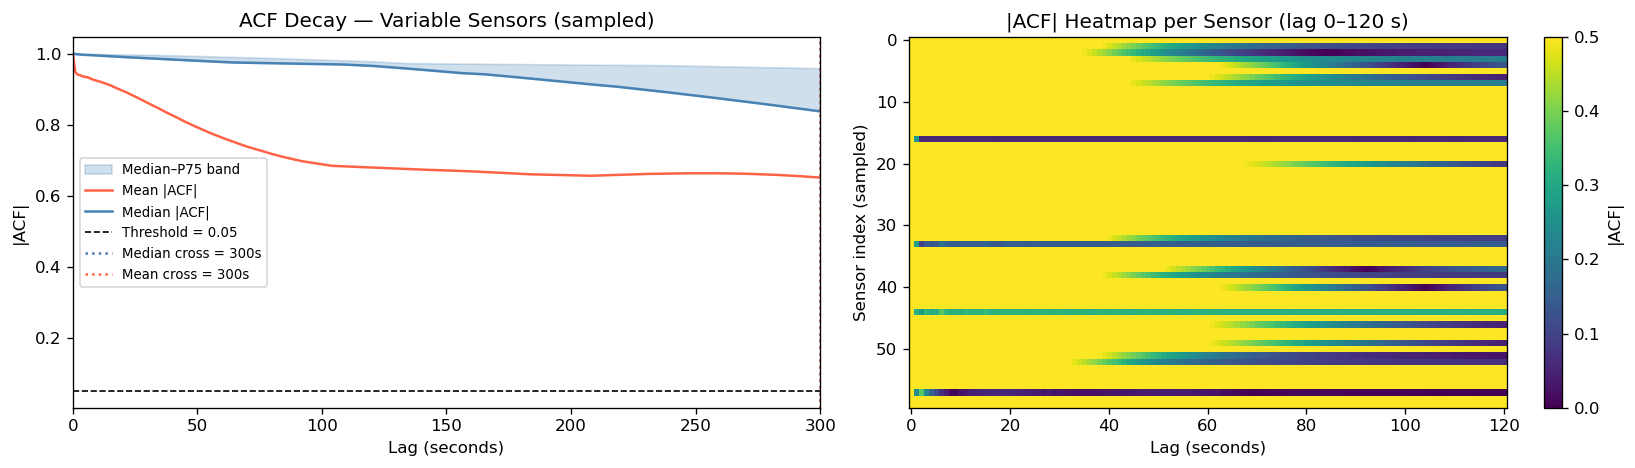

Fig saved → reports/acf_analysis.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left — aggregate ACF curves
ax = axes[0]
ax.fill_between(lags, acf_median, acf_p75, alpha=0.25, color='steelblue', label='Median–P75 band')
ax.plot(lags, acf_mean,   color='tomato',    lw=1.5, label='Mean |ACF|')
ax.plot(lags, acf_median, color='steelblue', lw=1.5, label='Median |ACF|')
ax.axhline(ACF_THRESH, color='k', ls='--', lw=1, label=f'Threshold = {ACF_THRESH}')
ax.axvline(cross_lag_median, color='steelblue', ls=':', lw=1.5,
           label=f'Median cross = {cross_lag_median}s')
ax.axvline(cross_lag_mean, color='tomato', ls=':', lw=1.5,
           label=f'Mean cross = {cross_lag_mean}s')
ax.set_xlabel('Lag (seconds)')
ax.set_ylabel('|ACF|')
ax.set_title('ACF Decay — Variable Sensors (sampled)')
ax.legend(fontsize=8)
ax.set_xlim(0, MAX_LAG)

# Right — heatmap of per-sensor ACF (first 120 lags)
ax2 = axes[1]
im = ax2.imshow(np.abs(acf_matrix[:, :121]), aspect='auto', cmap='viridis',
                vmin=0, vmax=0.5, origin='upper')
ax2.set_xlabel('Lag (seconds)')
ax2.set_ylabel('Sensor index (sampled)')
ax2.set_title('|ACF| Heatmap per Sensor (lag 0–120 s)')
plt.colorbar(im, ax=ax2, label='|ACF|')

plt.tight_layout()
plt.savefig('../reports/acf_analysis.png', bbox_inches='tight')
plt.show()
print('Fig saved → reports/acf_analysis.png')

---
## Section 2 — FFT Periodicity (Dominant Cycle Lengths)

For processes with recurring operational cycles (pump cycles, valve oscillations), the window should  
cover **at least one full dominant period** so the model sees a complete pattern.

We use Welch's method on each variable sensor and aggregate the dominant periods.


In [7]:
FS = 1.0           # 1 Hz — HAI sampling rate
PERIOD_MIN = 5     # seconds — ignore sub-5s noise
PERIOD_MAX = 600   # seconds — ignore very slow drifts

dominant_periods = []

for col_i in sampled_idx:
    series = X_all[:, col_i].astype(float)
    # Welch PSD
    freqs, psd = welch(series, fs=FS, nperseg=512)
    # Convert to periods; ignore DC (freq=0) and very short/long cycles
    with np.errstate(divide='ignore'):
        periods = 1.0 / freqs[1:]   # skip DC
    valid = (periods >= PERIOD_MIN) & (periods <= PERIOD_MAX)
    if valid.sum() == 0:
        continue
    dom_period = periods[valid][psd[1:][valid].argmax()]
    dominant_periods.append(dom_period)

dominant_periods = np.array(dominant_periods)
print(f'Dominant period stats across {len(dominant_periods)} sensors:')
print(f'  Median  = {np.median(dominant_periods):.1f} s')
print(f'  Mean    = {np.mean(dominant_periods):.1f} s')
print(f'  P25/P75 = {np.percentile(dominant_periods, 25):.1f} / {np.percentile(dominant_periods, 75):.1f} s')
print(f'  Max     = {dominant_periods.max():.1f} s')

Dominant period stats across 60 sensors:
  Median  = 512.0 s
  Mean    = 460.9 s
  P25/P75 = 512.0 / 512.0 s
  Max     = 512.0 s


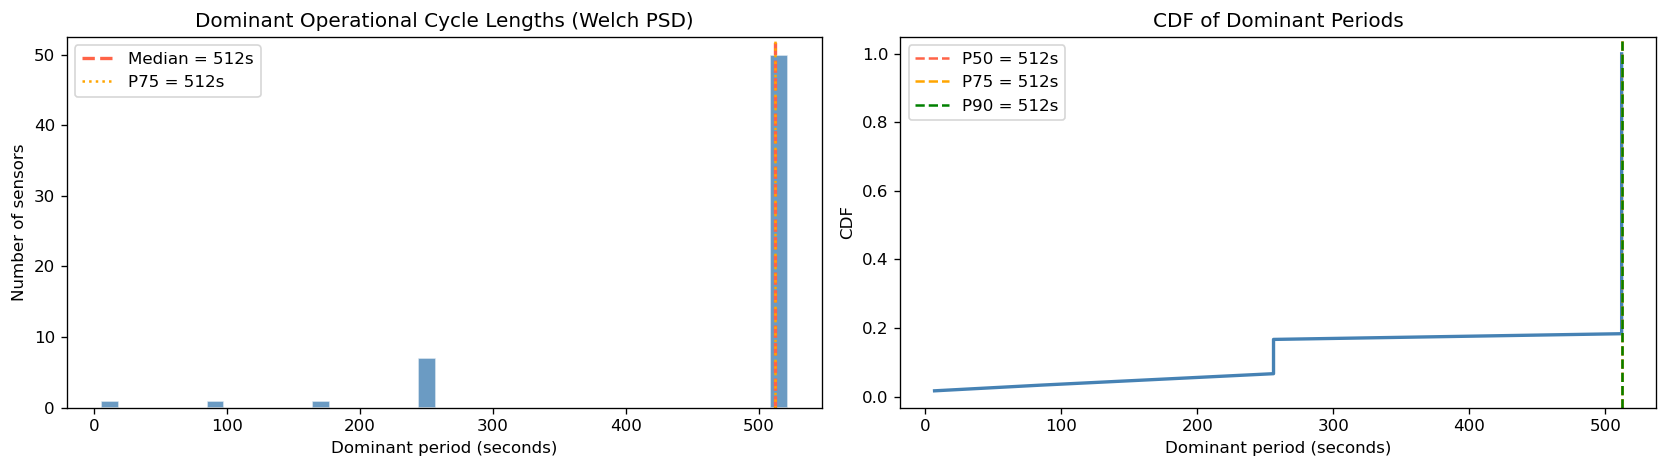

Fig saved → reports/fft_periodicity.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left — histogram of dominant periods
ax = axes[0]
bins = np.linspace(PERIOD_MIN, min(PERIOD_MAX, dominant_periods.max() + 10), 40)
ax.hist(dominant_periods, bins=bins, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.median(dominant_periods), color='tomato', lw=2, ls='--',
           label=f'Median = {np.median(dominant_periods):.0f}s')
ax.axvline(np.percentile(dominant_periods, 75), color='orange', lw=1.5, ls=':',
           label=f'P75 = {np.percentile(dominant_periods, 75):.0f}s')
ax.set_xlabel('Dominant period (seconds)')
ax.set_ylabel('Number of sensors')
ax.set_title('Dominant Operational Cycle Lengths (Welch PSD)')
ax.legend()

# Right — CDF
ax2 = axes[1]
sorted_p = np.sort(dominant_periods)
cdf = np.arange(1, len(sorted_p) + 1) / len(sorted_p)
ax2.plot(sorted_p, cdf, color='steelblue', lw=2)
for pct, col in [(50, 'tomato'), (75, 'orange'), (90, 'green')]:
    val = np.percentile(dominant_periods, pct)
    ax2.axvline(val, color=col, ls='--', lw=1.5, label=f'P{pct} = {val:.0f}s')
ax2.set_xlabel('Dominant period (seconds)')
ax2.set_ylabel('CDF')
ax2.set_title('CDF of Dominant Periods')
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/fft_periodicity.png', bbox_inches='tight')
plt.show()
print('Fig saved → reports/fft_periodicity.png')

---
## Section 3 — PCA Reconstruction Error vs Window Size

For each candidate window size we:
1. Slice the concatenated training data into non-overlapping windows (stride = window_size).
2. Flatten each window → `(n_windows, window_size × n_features)`.
3. Fit PCA with a fixed number of components (capturing ~95 % of single-timestep variance).
4. Measure the **mean reconstruction MSE** (proxy for information not captured).

The **elbow** in the curve marks where extra context stops helping — a natural upper bound.

> We sub-sample sensors and windows for speed.  Results are stable because the dataset is large.


In [9]:
CANDIDATE_WINDOWS = [10, 20, 30, 60, 90, 120, 180, 240, 300]
N_COMPONENTS_FRAC = 0.95   # keep enough PCs to explain 95% of per-step variance
MAX_WINDOWS       = 3000   # max windows to use per window size (speed)
N_SENSORS_USE     = min(80, len(variable_idx))   # subsample sensors

rng2 = np.random.default_rng(0)
sens_idx = rng2.choice(variable_idx, size=N_SENSORS_USE, replace=False)
X_sub = X_all[:, sens_idx]   # (N, N_SENSORS_USE)

# Determine PCA n_components from single-timestep PCA
pca_base = PCA(n_components=N_SENSORS_USE)
pca_base.fit(X_sub[:5000])  # fit on first 5000 rows
cumvar = np.cumsum(pca_base.explained_variance_ratio_)
n_comp_base = int(np.searchsorted(cumvar, N_COMPONENTS_FRAC)) + 1
print(f'Single-timestep PCA: {n_comp_base} components explain {N_COMPONENTS_FRAC*100:.0f}% variance')

results = []

for ws in CANDIDATE_WINDOWS:
    # Non-overlapping windows
    n_w = len(X_sub) // ws
    flat = X_sub[:n_w * ws].reshape(n_w, ws * N_SENSORS_USE).astype(np.float32)

    # Sub-sample
    if n_w > MAX_WINDOWS:
        idx = rng2.choice(n_w, MAX_WINDOWS, replace=False)
        flat = flat[idx]

    # PCA — scale components with window size so comparison is fair
    n_comp = min(n_comp_base * ws, flat.shape[0] - 1, flat.shape[1] - 1)
    n_comp = max(n_comp, 1)
    pca = PCA(n_components=n_comp)
    scores = pca.fit_transform(flat)
    recon  = pca.inverse_transform(scores)
    mse    = float(np.mean((flat - recon) ** 2))

    # Variance explained (ratio)
    var_exp = float(pca.explained_variance_ratio_.sum())

    results.append({'window_size': ws, 'mse': mse, 'var_explained': var_exp,
                    'n_windows': len(flat), 'n_comp': n_comp})
    print(f'  ws={ws:4d}s  mse={mse:.5f}  var_exp={var_exp:.3f}  n_windows={len(flat)}')

results_df = pd.DataFrame(results)
print('\n', results_df.to_string(index=False))

Single-timestep PCA: 10 components explain 95% variance
  ws=  10s  mse=0.00037  var_exp=1.000  n_windows=3000
  ws=  20s  mse=0.00019  var_exp=1.000  n_windows=3000
  ws=  30s  mse=0.00016  var_exp=1.000  n_windows=3000
  ws=  60s  mse=0.00012  var_exp=1.000  n_windows=3000
  ws=  90s  mse=0.00010  var_exp=1.000  n_windows=3000
  ws= 120s  mse=0.00008  var_exp=1.000  n_windows=3000
  ws= 180s  mse=0.00005  var_exp=1.000  n_windows=3000
  ws= 240s  mse=0.00002  var_exp=1.000  n_windows=3000
  ws= 300s  mse=0.00000  var_exp=1.000  n_windows=2987

  window_size          mse  var_explained  n_windows  n_comp
          10 3.661964e-04       0.999582       3000     100
          20 1.935996e-04       0.999783       3000     200
          30 1.596633e-04       0.999828       3000     300
          60 1.172900e-04       0.999866       3000     600
          90 9.786702e-05       0.999892       3000     900
         120 7.862995e-05       0.999914       3000    1200
         180 4.708909e-05  

In [10]:
# ── Elbow detection: second derivative of MSE curve ──────────────────────────
mse_vals = results_df['mse'].values
ws_vals  = results_df['window_size'].values

# Normalise MSE to [0,1] for elbow detection
mse_norm = (mse_vals - mse_vals.min()) / (mse_vals.max() - mse_vals.min() + 1e-12)

# Kneedle-style: distance from line connecting first and last point
x_norm = (ws_vals - ws_vals.min()) / (ws_vals.max() - ws_vals.min())
line   = x_norm  # straight line from (0,1) to (1,0) in normalised space ... approx
diff   = mse_norm - (1 - x_norm)   # difference from diagonal
elbow_idx = np.argmax(diff)         # point furthest from diagonal
elbow_ws  = ws_vals[elbow_idx]

print(f'Elbow detected at window_size = {elbow_ws} s')

Elbow detected at window_size = 300 s


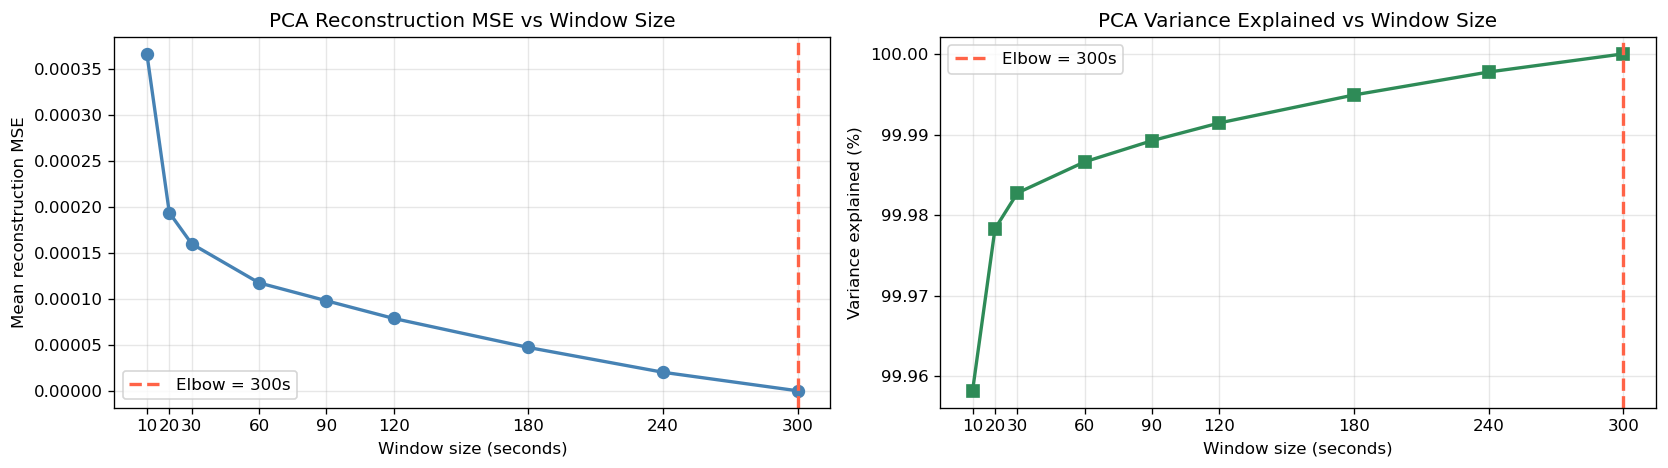

Fig saved → reports/pca_reconstruction.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left — MSE vs window size
ax = axes[0]
ax.plot(ws_vals, mse_vals, 'o-', color='steelblue', lw=2, ms=7)
ax.axvline(elbow_ws, color='tomato', ls='--', lw=2, label=f'Elbow = {elbow_ws}s')
ax.set_xlabel('Window size (seconds)')
ax.set_ylabel('Mean reconstruction MSE')
ax.set_title('PCA Reconstruction MSE vs Window Size')
ax.xaxis.set_major_locator(mticker.FixedLocator(ws_vals))
ax.legend()
ax.grid(alpha=0.3)

# Right — Variance explained
ax2 = axes[1]
ax2.plot(ws_vals, results_df['var_explained'].values * 100, 's-', color='seagreen', lw=2, ms=7)
ax2.axvline(elbow_ws, color='tomato', ls='--', lw=2, label=f'Elbow = {elbow_ws}s')
ax2.set_xlabel('Window size (seconds)')
ax2.set_ylabel('Variance explained (%)')
ax2.set_title('PCA Variance Explained vs Window Size')
ax2.xaxis.set_major_locator(mticker.FixedLocator(ws_vals))
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/pca_reconstruction.png', bbox_inches='tight')
plt.show()
print('Fig saved → reports/pca_reconstruction.png')

---
## Section 4 — Per-Split Comparison

Verify that ACF characteristics are consistent across all four training splits  
(a split-specific result would suggest the window choice is not robust).


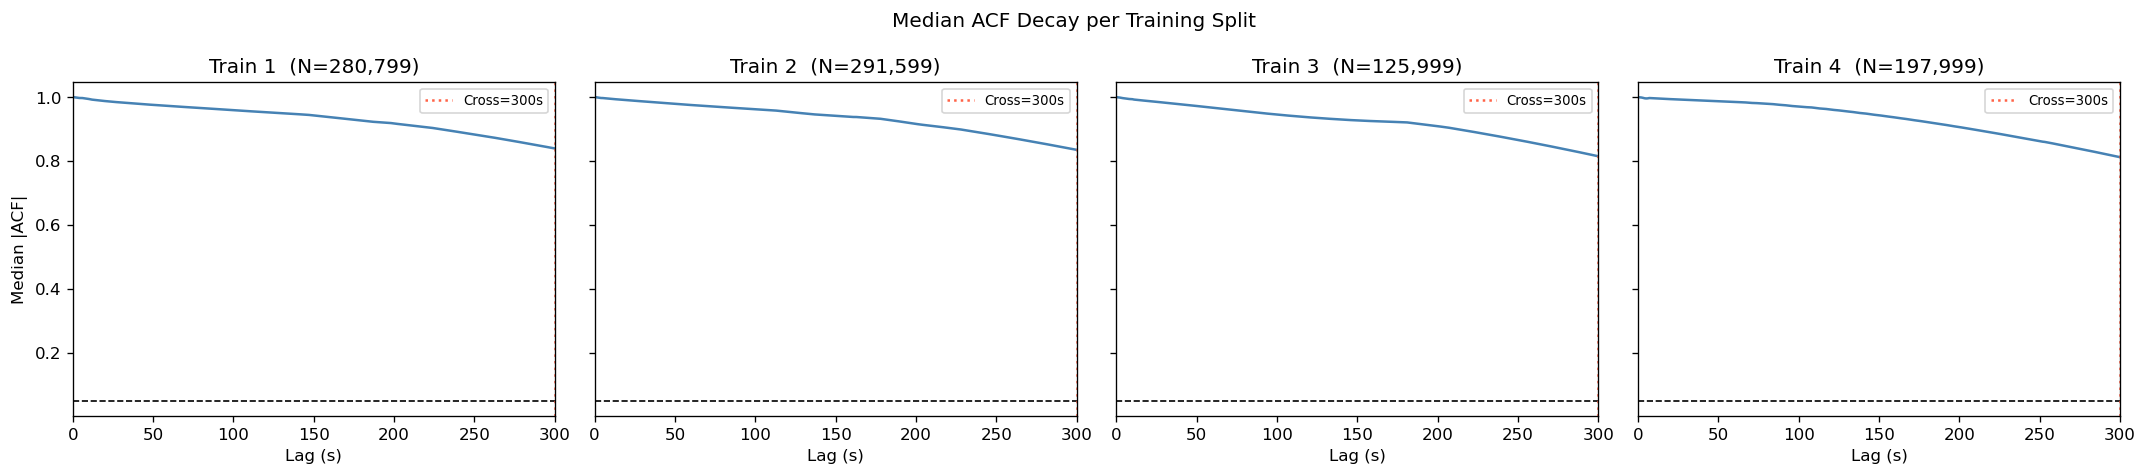

ACF cross-threshold lags per split:
  train1: 300s
  train2: 300s
  train3: 300s
  train4: 300s


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

split_cross_lags = {}

for ax, (split_num, X_split) in zip(axes, split_arrays.items()):
    # Use same sampled variable sensors (intersect with split length)
    acf_rows = []
    for col_i in sampled_idx:
        series = X_split[:, col_i].astype(float)
        try:
            acf_vals = acf(series, nlags=MAX_LAG, fft=True, missing='drop')
            acf_rows.append(np.abs(acf_vals))
        except Exception:
            pass
    mat = np.array(acf_rows, dtype=np.float32)
    med = np.nanmedian(mat, axis=0)
    cross = next((l for l in lags if med[l] < ACF_THRESH), MAX_LAG)
    split_cross_lags[split_num] = cross

    ax.plot(lags, med, color='steelblue', lw=1.5)
    ax.axhline(ACF_THRESH, color='k', ls='--', lw=1)
    ax.axvline(cross, color='tomato', ls=':', lw=1.5, label=f'Cross={cross}s')
    ax.set_title(f'Train {split_num}  (N={len(X_split):,})')
    ax.set_xlabel('Lag (s)')
    ax.legend(fontsize=8)
    ax.set_xlim(0, MAX_LAG)

axes[0].set_ylabel('Median |ACF|')
fig.suptitle('Median ACF Decay per Training Split', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/acf_per_split.png', bbox_inches='tight')
plt.show()

print('ACF cross-threshold lags per split:')
for s, lag in split_cross_lags.items():
    print(f'  train{s}: {lag}s')

---
## Section 5 — Summary & Recommendation


In [13]:
acf_evidence   = cross_lag_median            # lag where median ACF < threshold
fft_evidence   = np.median(dominant_periods) # median dominant period
pca_evidence   = elbow_ws                    # elbow in PCA MSE curve

# Conservative recommendation: take the max of ACF & FFT evidence,
# but don't exceed PCA elbow (diminishing returns).
lower_bound    = max(acf_evidence, fft_evidence)
recommendation = min(lower_bound, pca_evidence) if pca_evidence > lower_bound else pca_evidence

# Round to nearest value in candidate list for practical use
practical_rec  = min(CANDIDATE_WINDOWS, key=lambda w: abs(w - recommendation))

print('=' * 55)
print('  WINDOW SIZE ANALYSIS — SUMMARY')
print('=' * 55)
print(f'  ACF evidence (median ACF < {ACF_THRESH}):  {acf_evidence:.0f} s')
print(f'  FFT evidence (median dom. period):  {fft_evidence:.0f} s')
print(f'  PCA evidence (elbow in MSE curve):  {pca_evidence:.0f} s')
print(f'  ACF per-split range:  {min(split_cross_lags.values())}–{max(split_cross_lags.values())} s')
print('-' * 55)
print(f'  Continuous recommendation:  {recommendation:.0f} s')
print(f'  Nearest candidate value:    {practical_rec} s  <-- USE THIS')
print('=' * 55)
print()
print('Candidate window sizes tested:')
print(results_df[['window_size', 'mse', 'var_explained']].to_string(index=False))

  WINDOW SIZE ANALYSIS — SUMMARY
  ACF evidence (median ACF < 0.05):  300 s
  FFT evidence (median dom. period):  512 s
  PCA evidence (elbow in MSE curve):  300 s
  ACF per-split range:  300–300 s
-------------------------------------------------------
  Continuous recommendation:  300 s
  Nearest candidate value:    300 s  <-- USE THIS

Candidate window sizes tested:
 window_size          mse  var_explained
          10 3.661964e-04       0.999582
          20 1.935996e-04       0.999783
          30 1.596633e-04       0.999828
          60 1.172900e-04       0.999866
          90 9.786702e-05       0.999892
         120 7.862995e-05       0.999914
         180 4.708909e-05       0.999949
         240 2.014023e-05       0.999978
         300 3.434058e-11       1.000000


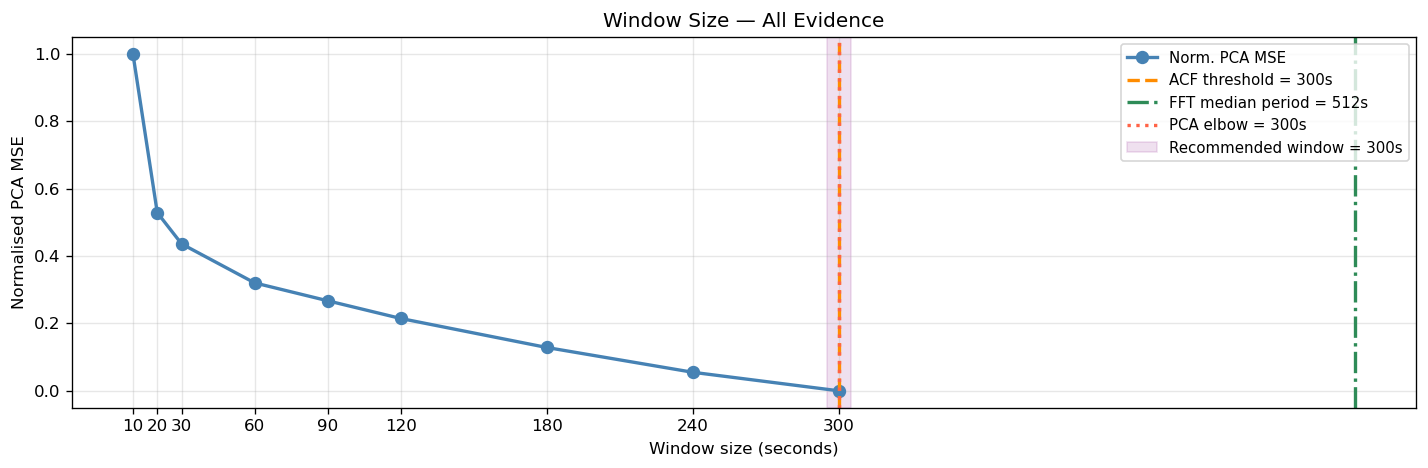

Fig saved → reports/window_size_summary.png


In [14]:
# ── Summary figure: all evidence on one plot ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

# Normalised MSE curve as background signal
ax.plot(ws_vals, mse_norm, 'o-', color='steelblue', lw=2, ms=7, label='Norm. PCA MSE')

# Evidence lines
ax.axvline(acf_evidence, color='darkorange', ls='--', lw=2,
           label=f'ACF threshold = {acf_evidence:.0f}s')
ax.axvline(fft_evidence, color='seagreen',   ls='-.', lw=2,
           label=f'FFT median period = {fft_evidence:.0f}s')
ax.axvline(pca_evidence, color='tomato',     ls=':',  lw=2,
           label=f'PCA elbow = {pca_evidence:.0f}s')

# Recommendation
ax.axvspan(practical_rec - 5, practical_rec + 5, alpha=0.12, color='purple',
           label=f'Recommended window = {practical_rec}s')

ax.set_xlabel('Window size (seconds)')
ax.set_ylabel('Normalised PCA MSE')
ax.set_title('Window Size — All Evidence')
ax.xaxis.set_major_locator(mticker.FixedLocator(ws_vals))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/window_size_summary.png', bbox_inches='tight')
plt.show()
print('Fig saved → reports/window_size_summary.png')